In [1]:
import pandas as pd
name = "all_series_matrix"
expression_df= pd.read_csv(f"Data/{name}.csv", index_col=0)  # Save as CSV
expression_df.head()

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,overall survival days,overall survival event,endocrine treated,chemo treated
F1,43,9.0,2,0,0.0,0.0,0.0,1.0,2,0,2367,0,0.0,1.0
F2,48,14.0,0,1,1.0,1.0,0.0,0.0,1,2,2367,0,1.0,1.0
F3,69,27.0,1,1,1.0,1.0,0.0,1.0,2,3,2168,1,1.0,1.0
F4,39,51.0,0,1,1.0,1.0,1.0,1.0,2,2,2416,0,1.0,1.0
F5,73,60.0,1,1,1.0,1.0,0.0,0.0,1,4,2389,0,1.0,0.0


In [2]:
len(expression_df)

3409

In [3]:
expression_df['lymph node status'].value_counts()

lymph node status
 0    2099
 1    1209
-1     101
Name: count, dtype: int64

In [4]:
# convert to boolean columns 5 to 8 and 12 to end
for i in range(4, 9):
    expression_df.iloc[:, i] = expression_df.iloc[:, i].astype(bool)
for i in range(11, expression_df.shape[1]):
    expression_df.iloc[:, i] = expression_df.iloc[:, i].astype(bool)
expression_df.head()

/tmp/ipykernel_281515/4071991278.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'F1           False
F2            True
F3            True
F4            True
F5            True
             ...  
F3028repl     True
F3058repl     True
F3127repl     True
F3250repl    False
F3265repl     True
Name: er status, Length: 3409, dtype: bool' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  expression_df.iloc[:, i] = expression_df.iloc[:, i].astype(bool)
/tmp/ipykernel_281515/4071991278.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'F1           False
F2            True
F3            True
F4            True
F5            True
             ...  
F3028repl     True
F3058repl     True
F3127repl     True
F3250repl    False
F3265repl     True
Name: pgr status, Length: 3409, dtype: bool' has dtype incompatible 

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,overall survival days,overall survival event,endocrine treated,chemo treated
F1,43,9.0,2,0,False,False,False,True,True,0,2367,False,False,True
F2,48,14.0,0,1,True,True,False,False,True,2,2367,False,True,True
F3,69,27.0,1,1,True,True,False,True,True,3,2168,True,True,True
F4,39,51.0,0,1,True,True,True,True,True,2,2416,False,True,True
F5,73,60.0,1,1,True,True,False,False,True,4,2389,False,True,False


In [39]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.linear_model import Lasso

# Load your data (replace with your actual file paths)
data = expression_df
# Preprocess the data
# 1. Handle missing values
data = data.fillna(data.mean()) # Simple imputation - replace with more sophisticated methods if needed

# 2. Select features and target
X = data.drop(['age at diagnosis','tumor size','lymph node group','lymph node status', 'pam50 subtype','overall survival days', 'overall survival event'], axis=1) # Drop survival columns for feature matrix
y = data[[ 'overall survival event','overall survival days']].copy() # Survival data as a separate dataframe
y['overall survival event'] = y['overall survival event'].astype(bool) # Needs to be boolean

#X = X.loc[:, X.dtypes == 'bool']  # Keep only boolean columns

# Create structured array for survival data
y = y.to_records(index=False)

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 4. Scale the data
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)
# save scaler
#with open('scaler_survival_clinical.pkl', 'wb') as f:
#    pickle.dump(scaler, f)

# Cox Model with Lasso Regularization
estimator = CoxnetSurvivalAnalysis(l1_ratio=.1, alpha_min_ratio=0.01,  fit_baseline_model=True) # l1_ratio=1.0 for Lasso, adjust alpha
estimator.fit(X_train, y_train)

# save estimator
#with open('estimator_survival_clinical.pkl', 'wb') as f:
#    pickle.dump(estimator, f)

# Predict on the test set
y_pred = estimator.predict(X=X_test)


# Evaluate the model
c_index = concordance_index_censored(y_test['overall survival event'], y_test['overall survival days'], y_pred)
print(f"C-index: {c_index[0]}")

C-index: 0.6974102384406017


In [36]:
X_test

,er status,pgr status,her2 status,ki67 status,nhg,endocrine treated,chemo treated
F35,True,True,False,True,True,True,False
F1581repl,True,True,False,False,False,True,True
F2646,True,True,False,False,False,True,False
F1550,True,True,False,True,True,True,False
F237,True,True,False,True,True,True,True
...,...,...,...,...,...,...,...
F1105,True,True,False,False,True,True,False
F2568,True,True,False,True,True,True,False
F3050,True,True,False,True,True,True,True
F2780,True,True,False,True,True,True,True


Patient 1 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00033699, 0.00033699, 0.00067459, ..., 0.13397739, 0.13397739,
       0.13397739]), a=np.float64(1.4129083402705849), b=0.0)
Patient 2 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00033699, 0.00033699, 0.00067459, ..., 0.13397739, 0.13397739,
       0.13397739]), a=np.float64(0.26686038424205294), b=0.0)
Patient 3 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00033699, 0.00033699, 0.00067459, ..., 0.13397739, 0.13397739,
       0.13397739]), a=np.float64(0.636861178652639), b=0.0)
Patient 4 - Cumulative Hazard Function: StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00033699, 0.00033699, 0.00067459, ..., 0.13397739, 0.13397739,
       0.13397739]), a=np.float64(1.4129083402705849), b=0.0)
Patient 5 - 

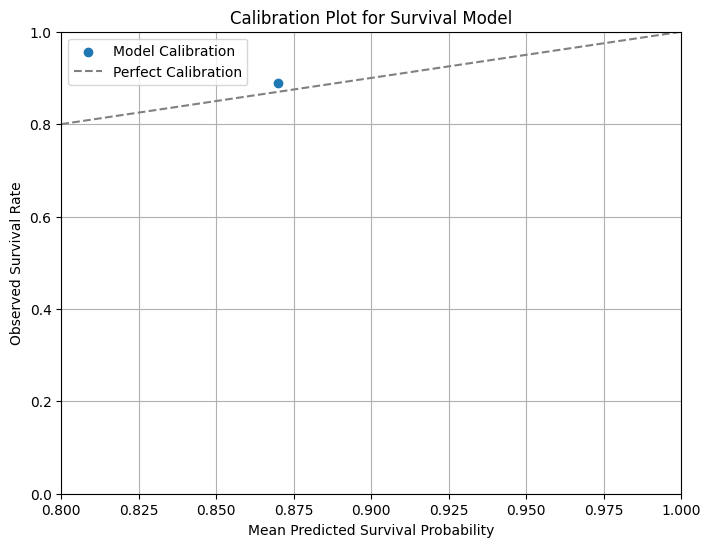

In [38]:
import numpy as np
import matplotlib.pyplot as plt


time = 3650  # 10 years in days
# 1. Predict Survival Probabilities (as described above)
cumulative_hazard_functions = estimator.predict_cumulative_hazard_function(X_test)
survival_probabilities = []
for i, chf in enumerate(cumulative_hazard_functions):
    print(f"Patient {i+1} - Cumulative Hazard Function: {chf}")
    try:
        # chf.x is the times at which the function has steps
        # chf.y is the value of the function at each time step
        time_index = np.searchsorted(chf.x, time, side="right") - 1  # Find the index just before time
        if time_index >= 0:
            cumulative_hazard = chf.y[time_index]
        else:
            cumulative_hazard = 0  # Handle cases where 365 is before the first step
    except Exception as e:
        cumulative_hazard = chf(time)  # Evaluate the function at time
    survival_probabilities.append(np.exp(-cumulative_hazard))

survival_probabilities = np.array(survival_probabilities)

# 2. Binning - Adjusted for Probabilities Around 0.9
n_bins = 10
bin_start = 0.8  # Start binning at 0.8
bin_end = 1.0    # End binning at 1.0
bins = np.linspace(bin_start, bin_end, n_bins + 1) # Focus bins on the 0.8-1.0 range
binned_predictions = np.digitize(survival_probabilities, bins) - 1  # Subtract 1 to get 0-based bin indices

# 3. Calculate Observed Survival Rates
observed_survival_rates = []
bin_midpoints = []

for i in range(n_bins):
    # Find patients that fall into bin i
    patients_in_bin = (binned_predictions == i)
    n_patients_in_bin = np.sum(patients_in_bin)

    if n_patients_in_bin > 0:
        #calculate survival based on real data, so
        # y_test_survival['overall survival event'] -> True if the patient died
        # y_test_survival['overall survival days'] -> Time untill dead
        # The survivals are the patients that overall survival days>365 or that they didn't died (overall survival event is False)
        # so the final patients_survived is (y_test_survival['overall survival days']>365) | (y_test_survival['overall survival event']==False)
        patients_survived = ((y_test['overall survival days']>time) | (y_test['overall survival event']==False))[patients_in_bin]
        #Patients survived
        n_survived = np.sum(patients_survived)

        observed_survival_rate = n_survived / n_patients_in_bin
        observed_survival_rates.append(observed_survival_rate)
        bin_midpoints.append((bins[i] + bins[i+1]) / 2)
    else:
        # Avoid empty bins
        observed_survival_rates.append(np.nan)
        bin_midpoints.append((bins[i] + bins[i + 1]) / 2)  # Still keep the midpoint for consistency

# 4. Plot the Calibration Curve
plt.figure(figsize=(8, 6))
valid_bins = ~np.isnan(observed_survival_rates)  # Filter out NaN values
plt.scatter(np.array(bin_midpoints)[valid_bins], np.array(observed_survival_rates)[valid_bins], label="Model Calibration")
plt.plot([bin_start, bin_end], [bin_start, bin_end], linestyle="--", color="gray", label="Perfect Calibration")  # Diagonal line
plt.xlabel("Mean Predicted Survival Probability")
plt.ylabel("Observed Survival Rate")
plt.title("Calibration Plot for Survival Model")
plt.xlim([bin_start, bin_end])  # Adjust x-axis limits
plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
max(survival_probabilities) - min(survival_probabilities)

np.float64(0.9927922836264723)

Min Survival Probability: 0.873481651914938
Max Survival Probability: 0.873481651914938


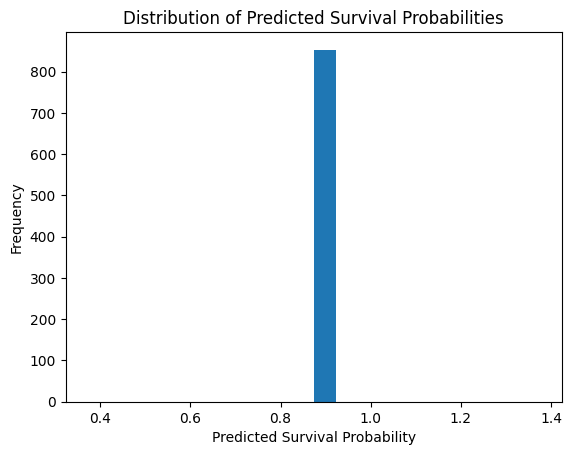

In [19]:
print("Min Survival Probability:", np.min(survival_probabilities))
print("Max Survival Probability:", np.max(survival_probabilities))
plt.hist(survival_probabilities, bins=20)  # Plot a histogram
plt.xlabel("Predicted Survival Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Survival Probabilities")
plt.show()

In [ ]:
selected_clinical_features_for_prediction  = X_train.columns[estimator.active_features_].tolist()
# Save selected features
#with open('selected_clinical_features_for_prediction.txt', 'wb') as f:
#    pickle.dump(selected_clinical_features_for_prediction, f)

NameError: name 'X_train' is not defined

In [144]:
X_train

,er status,pgr status,her2 status,ki67 status,nhg,endocrine treated,chemo treated
F2614,True,False,True,True,True,False,True
F2835,True,True,False,True,True,True,False
F1375,True,True,False,True,True,True,True
F228,True,True,False,False,True,True,True
F611,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...
F1231,False,False,False,True,True,False,True
F1266,True,True,False,False,True,True,True
F1449,True,True,False,False,True,True,False
F939,True,True,False,False,False,True,False


In [145]:
pd.DataFrame(X_test)

,er status,pgr status,her2 status,ki67 status,nhg,endocrine treated,chemo treated
F35,True,True,False,True,True,True,False
F1581repl,True,True,False,False,False,True,True
F2646,True,True,False,False,False,True,False
F1550,True,True,False,True,True,True,False
F237,True,True,False,True,True,True,True
...,...,...,...,...,...,...,...
F1105,True,True,False,False,True,True,False
F2568,True,True,False,True,True,True,False
F3050,True,True,False,True,True,True,True
F2780,True,True,False,True,True,True,True


In [147]:
result =estimator.predict_cumulative_hazard_function(X_test)

In [148]:
result

array([StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00034055, 0.00034055, 0.00068169, ..., 0.13526815, 0.13526815,
              0.13526815]), a=np.float64(1.3640307742094702), b=0.0)                                                                                   ,
       StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00034055, 0.00034055, 0.00068169, ..., 0.13526815, 0.13526815,
              0.13526815]), a=np.float64(0.29144217509917625), b=0.0)                                                                                  ,
       StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00034055, 0.00034055, 0.00068169, ..., 0.13526815, 0.13526815,
              0.13526815]), a=np.float64(0.6953559532568994), b=0.0)                                                                                   ,
       StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array

In [47]:
result_train =estimator.predict_cumulative_hazard_function(X_train)


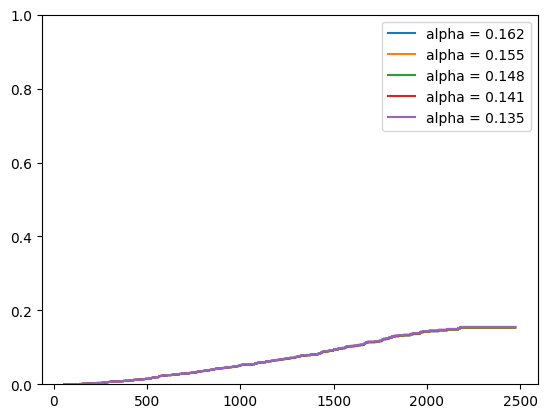

In [52]:
chf_funcs = {}
for alpha in estimator.alphas_[:5]:
     chf_funcs[alpha] = estimator.predict_cumulative_hazard_function(
         X.iloc[:1], alpha=alpha)

#Plot the estimated cumulative hazard functions.

for alpha, chf_alpha in chf_funcs.items():
     for fn in chf_alpha:
         plt.step(fn.x, fn(fn.x), where="post",
                  label=f"alpha = {alpha:.3f}")

plt.ylim(0, 1)
plt.legend()
plt.show()

In [53]:
chf_funcs

{np.float64(0.16209786785771346): array([StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00039124, 0.00039124, 0.00078278, ..., 0.15264814, 0.15264814,
               0.15264814]), a=np.float64(1.0), b=0.0)                                                                                                  ],
       dtype=object),
 np.float64(0.15473026959175432): array([StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00039124, 0.00039124, 0.00078278, ..., 0.15265794, 0.15265794,
               0.15265794]), a=np.float64(1.0038906627055164), b=0.0)                                                                                   ],
       dtype=object),
 np.float64(0.1476975400376786): array([StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00039123, 0.00039123, 0.00078277, ..., 0.15266759, 0.15266759,
               0.15266759]), a=np.float64(1.0079452775185829), b=0.0)                    

In [51]:
result_train[0]

StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.0003359 , 0.0003359 , 0.00067242, ..., 0.13359533, 0.13359533,
       0.13359533]), a=np.float64(1.58055450895163), b=0.0)

In [150]:
y_test

rec.array([(False, 2335), (False, 1880), (False, 2433), (False, 1963),
           (False, 1360), (False, 1458), (False, 2112), (False, 2325),
           (False, 1577), (False, 1215), (False, 2388), (False, 1051),
           (False,  872), (False, 2081), (False, 1766), (False, 1704),
           (False, 1382), (False, 1128), (False, 1130), (False, 2089),
           (False, 1482), (False, 1640), (False, 1137), ( True, 1379),
           (False, 1562), (False, 2215), (False, 1226), (False, 1152),
           (False, 1572), (False, 1821), (False, 1759), (False, 1529),
           (False, 1171), (False, 1961), (False,  903), (False, 2152),
           (False,  982), (False, 2311), (False, 1927), (False, 1782),
           ( True, 1104), (False, 1478), (False,  904), (False,  905),
           ( True,  141), ( True, 1500), (False, 2181), (False, 1296),
           ( True, 1088), (False, 2118), (False, 1612), (False, 1748),
           (False, 1235), (False, 1513), (False, 1193), (False, 2117),
      

In [151]:
y_pred


array([ 0.31044412, -1.23291366, -0.3633314 ,  0.31044412, -0.55913814,
        0.27345395, -0.3633314 , -0.55913814, -0.55913814,  1.38691663,
        0.31044412, -0.55913814,  0.27345395, -0.3633314 ,  0.06996202,
        0.9429426 ,  1.14643453, -0.15983947,  0.51393605, -0.55913814,
       -0.574743  , -0.55913814, -0.574743  ,  0.31044412, -0.55913814,
        0.51733437,  0.51733437, -0.15983947,  0.06996202,  0.31044412,
        0.29823758, -0.55913814, -0.55913814, -0.15983947, -0.3633314 ,
        0.31044412,  0.31044412, -0.55913814, -0.35564621, -0.3633314 ,
       -0.79962024,  0.06996202,  0.50172951, -0.574743  ,  0.06996202,
        0.51733437, -0.3633314 ,  0.06996202,  0.51733437,  0.31044412,
        0.06996202,  0.06996202, -0.79962024, -0.79962024, -0.3633314 ,
       -0.79962024,  0.50172951, -0.79962024,  0.31044412,  0.06996202,
        0.51393605,  1.38691663,  0.31044412, -0.55913814,  0.06996202,
       -0.61173317, -0.79962024, -0.55913814,  0.31044412, -0.36

In [152]:
result

array([StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00034055, 0.00034055, 0.00068169, ..., 0.13526815, 0.13526815,
              0.13526815]), a=np.float64(1.3640307742094702), b=0.0)                                                                                   ,
       StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00034055, 0.00034055, 0.00068169, ..., 0.13526815, 0.13526815,
              0.13526815]), a=np.float64(0.29144217509917625), b=0.0)                                                                                  ,
       StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00034055, 0.00034055, 0.00068169, ..., 0.13526815, 0.13526815,
              0.13526815]), a=np.float64(0.6953559532568994), b=0.0)                                                                                   ,
       StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array

In [153]:
pd.DataFrame(result[0].y.astype(float), result[0].x, columns=['Cumulative Hazard']).head()

,Cumulative Hazard
56.0,0.000341
59.0,0.000341
136.0,0.000682
152.0,0.001023
156.0,0.001365


In [154]:
result[0].x

array([  56.,   59.,  136., ..., 2472., 2473., 2474.])

In [155]:
pd.DataFrame(result)

,0
0,"StepFunction(x=array([ 56., 59., 136., ......"
1,"StepFunction(x=array([ 56., 59., 136., ......"
2,"StepFunction(x=array([ 56., 59., 136., ......"
3,"StepFunction(x=array([ 56., 59., 136., ......"
4,"StepFunction(x=array([ 56., 59., 136., ......"
...,...
848,"StepFunction(x=array([ 56., 59., 136., ......"
849,"StepFunction(x=array([ 56., 59., 136., ......"
850,"StepFunction(x=array([ 56., 59., 136., ......"
851,"StepFunction(x=array([ 56., 59., 136., ......"


In [72]:
type(X_train)

numpy.ndarray

In [73]:
# set all values to 1 



In [156]:
X.columns

Index(['er status', 'pgr status', 'her2 status', 'ki67 status', 'nhg',
       'endocrine treated', 'chemo treated'],
      dtype='object')

In [157]:
X.columns = X.columns.astype(str)

In [76]:
#save estimator
with open('estimator_survival_clinical.pkl', 'wb') as f:
    pickle.dump(estimator, f)

In [41]:
x_test_df = pd.DataFrame(X_test.copy())
x_test_df.columns = X.columns
X_test_endocrine = x_test_df.copy()
X_test_endocrine['endocrine treated'] = True# You are setting endocrine as 1 bbuth the previous coumnns were true and false also, chemo keeps true and false, maybe you want chemo 0
X_test_endocrine['chemo treated'] = False
X_test_chemo = x_test_df.copy()
X_test_chemo['chemo treated'] = True
X_test_chemo['endocrine treated'] = False
X_test_both = x_test_df.copy()
X_test_both['endocrine treated'] = True
X_test_both['chemo treated'] = True
X_test_none = x_test_df.copy()
X_test_none['endocrine treated'] = False
X_test_none['chemo treated'] = False


y_pred_endocrine = estimator.predict(X_test_endocrine)
y_pred_chemo = estimator.predict(X_test_chemo)
y_pred_both = estimator.predict(X_test_both)
y_pred_none = estimator.predict(X_test_none)

In [45]:
# make a dataframe with the predictions
predictions_df = pd.DataFrame({
    'endocrine_treated': y_pred_endocrine,
    'chemo_treated': y_pred_chemo,
    'both_treated': y_pred_both,
    'none_treated': y_pred_none
})
predictions_df

,endocrine_treated,chemo_treated,both_treated,none_treated
0,0.350241,-0.238541,-0.529614,0.641313
1,-0.458020,-1.046803,-1.337875,-0.166948
2,-0.458020,-1.046803,-1.337875,-0.166948
3,0.350241,-0.238541,-0.529614,0.641313
4,0.350241,-0.238541,-0.529614,0.641313
...,...,...,...,...
848,0.061370,-0.527413,-0.818485,0.352442
849,0.350241,-0.238541,-0.529614,0.641313
850,0.350241,-0.238541,-0.529614,0.641313
851,0.350241,-0.238541,-0.529614,0.641313


In [44]:
len(X_test_endocrine)

853

In [ ]:
cumulative_hazard

In [160]:
X_test_endocrine

,er status,pgr status,her2 status,ki67 status,nhg,endocrine treated,chemo treated
F35,True,True,False,True,True,True,False
F1581repl,True,True,False,False,False,True,False
F2646,True,True,False,False,False,True,False
F1550,True,True,False,True,True,True,False
F237,True,True,False,True,True,True,False
...,...,...,...,...,...,...,...
F1105,True,True,False,False,True,True,False
F2568,True,True,False,True,True,True,False
F3050,True,True,False,True,True,True,False
F2780,True,True,False,True,True,True,False


In [171]:
best_treatments = []
for i in range(len(X_test)):
    risks = {
        "endocrine": y_pred_endocrine[i],
        "chemo": y_pred_chemo[i],
        "both": y_pred_both[i],
        "none": y_pred_none[i],
    }
    best_treatment = min(risks, key=risks.get)  # Find the treatment with the minimum risk
    best_treatments.append(best_treatment)

print(best_treatments) # This will tell you the best treatment for each patient

['both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both', 'both',

In [172]:
all_pred = pd.DataFrame({
    "endocrine": y_pred_endocrine,
    "chemo": y_pred_chemo,
    "both": y_pred_both,
    "none": y_pred_none,
    "best_treatment": best_treatments
}, index=X_test.index)
all_pred.head()

,endocrine,chemo,both,none,best_treatment
F35,0.310444,-0.355646,-0.559138,0.513936,both
F1581repl,-0.363331,-1.029422,-1.232914,-0.159839,both
F2646,-0.363331,-1.029422,-1.232914,-0.159839,both
F1550,0.310444,-0.355646,-0.559138,0.513936,both
F237,0.310444,-0.355646,-0.559138,0.513936,both


In [175]:
X_test_endocrine.iloc[i-1]

er status             True
pgr status            True
her2 status          False
ki67 status           True
nhg                   True
endocrine treated     True
chemo treated        False
Name: F2780, dtype: bool

In [79]:
best_treatments

['endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endocrine',
 'endo

In [80]:

from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt
import numpy as np

# Assuming estimator is your fitted CoxnetSurvivalAnalysis model
# and you have X_test_scaled as your scaled test data

# Set fit_baseline_model=True and alpha argument
# Now you can predict the cumulative hazard function
# For each patient, we have a function that tells us the hazard over time
cumulative_hazard_functions = estimator.predict_cumulative_hazard_function(X_test)

#To get survival probability for a single time point:
# time_point = 365  # e.g., 365 days
# survival_probabilities = [np.exp(-chf(time_point)) for chf in cumulative_hazard_functions]
# print(survival_probabilities)

# Now you can simulate cumulative_hazard_functions
# Same as before
X_test_endocrine_scaled = scaler.transform(X_test_endocrine)
X_test_chemo_scaled = scaler.transform(X_test_chemo)
X_test_both_scaled = scaler.transform(X_test_both)
X_test_none_scaled = scaler.transform(X_test_none)

chf_endocrine = estimator.predict_cumulative_hazard_function(X_test_endocrine_scaled)
chf_chemo = estimator.predict_cumulative_hazard_function(X_test_chemo_scaled)
chf_both = estimator.predict_cumulative_hazard_function(X_test_both_scaled)
chf_none = estimator.predict_cumulative_hazard_function(X_test_none_scaled)

#Choose treatment
best_treatments = []
time_point = 365*5  # e.g., 365 days
for i in range(len(X_test)):
    hazards = {
        "endocrine": chf_endocrine[i](time_point),
        "chemo": chf_chemo[i](time_point),
        "both": chf_both[i](time_point),
        "none": chf_none[i](time_point),
    }
    best_treatment = min(hazards, key=hazards.get)  # Find the treatment with the minimum risk
    best_treatments.append(best_treatment)

print(best_treatments) # This will tell you the best treatment for each patient

['endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine', 'endocrine'

In [81]:
cumulative_hazard_functions[0]

StepFunction(x=array([  56.,   59.,  136., ..., 2472., 2473., 2474.]), y=array([0.00026021, 0.00026021, 0.00052072, ..., 0.11169111, 0.11169111,
       0.11169111]), a=np.float64(0.8684959233821599), b=0.0)

In [82]:
type(cumulative_hazard_functions)

numpy.ndarray

In [83]:
X_test.shape

(853, 12)

Survival Probability = exp(-Cumulative Hazard)

In [84]:
import numpy as np
import pandas as pd

# Assuming you have:
# - estimator: Your trained CoxnetSurvivalAnalysis model
# - X_test: Your test data (before scaling) - the original dataframe to add the new survival data to
# - X_test_scaled: Your scaled test data (used for prediction)
# - chf_none: list of cumulative hazard functions for the test set

# 1. Choose Time Point(s)
time_points = [365, 1095, 1825]  # 1 year, 3 years, 5 years (in days)
X_train_df = pd.DataFrame(X_train, columns=X.columns)  # Convert to DataFrame for easier handling
# 2.  Calculate Cumulative Hazard Functions (if you haven't already)
cumulative_hazard_functions = estimator.predict_cumulative_hazard_function(X_train_df)

#3. Calculate Survival Probabilities and Add to DataFrame
for i, time_point in enumerate(time_points):
    survival_probabilities = [np.exp(-chf(time_point)) for chf in cumulative_hazard_functions]
    X_train_df[f'survival_probability_{time_point}_days'] = survival_probabilities



time_points = [365, 1095, 1825]  # 1 year, 3 years, 5 years (in days)
x_test_df = pd.DataFrame(X_test, columns=X.columns)  # Convert to DataFrame for easier handling
# 2.  Calculate Cumulative Hazard Functions (if you haven't already)
cumulative_hazard_functions = estimator.predict_cumulative_hazard_function(x_test_df)

#3. Calculate Survival Probabilities and Add to DataFrame
for i, time_point in enumerate(time_points):
    survival_probabilities = [np.exp(-chf(time_point)) for chf in cumulative_hazard_functions]
    x_test_df[f'survival_probability_{time_point}_days'] = survival_probabilities

x_test_df.head()

/home/karen/Documents/GitHub/rnaseq-breast-cancer-ai/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/home/karen/Documents/GitHub/rnaseq-breast-cancer-ai/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(


,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated,survival_probability_365_days,survival_probability_1095_days,survival_probability_1825_days
0,0.167020,-0.235522,-1.353553,1.284742,0.374916,0.48208,-0.354952,0.835667,0.400953,0.956918,0.53936,-0.841080,0.995208,0.965307,0.922197
1,-1.050095,-0.488171,-1.353553,1.284742,0.374916,0.48208,-0.354952,-1.196649,-2.494061,-0.041809,0.53936,1.188948,0.998012,0.985483,0.967012
2,-0.061189,0.017128,-1.353553,1.284742,0.374916,0.48208,-0.354952,-1.196649,-2.494061,-0.041809,0.53936,-0.841080,0.995266,0.965723,0.923110
3,0.243090,-0.319738,0.695414,-0.615605,0.374916,0.48208,-0.354952,0.835667,0.400953,-0.041809,0.53936,-0.841080,0.994085,0.957329,0.904809
4,-0.897956,-1.498770,-1.353553,1.284742,0.374916,0.48208,-0.354952,0.835667,0.400953,0.956918,0.53936,1.188948,0.998399,0.988293,0.973348


In [85]:
pd.DataFrame(y_test).head()

,overall survival event,overall survival days
0,False,2335
1,False,1880
2,False,2433
3,False,1963
4,False,1360


In [86]:
x_test_df['survival_probability_1825_days'].min()

np.float64(0.21055780081313186)

In [87]:
x_test_df['survival_probability_365_days'].min()

np.float64(0.911733634711503)

In [88]:
X_train_df['survival_probability_365_days'].min()

np.float64(0.8813997864244582)

In [89]:
X_train_df['survival_probability_1825_days'].min()

np.float64(0.11901782988010978)

In [90]:
x_test_df

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated,survival_probability_365_days,survival_probability_1095_days,survival_probability_1825_days
0,0.167020,-0.235522,-1.353553,1.284742,0.374916,0.48208,-0.354952,0.835667,0.400953,0.956918,0.53936,-0.841080,0.995208,0.965307,0.922197
1,-1.050095,-0.488171,-1.353553,1.284742,0.374916,0.48208,-0.354952,-1.196649,-2.494061,-0.041809,0.53936,1.188948,0.998012,0.985483,0.967012
2,-0.061189,0.017128,-1.353553,1.284742,0.374916,0.48208,-0.354952,-1.196649,-2.494061,-0.041809,0.53936,-0.841080,0.995266,0.965723,0.923110
3,0.243090,-0.319738,0.695414,-0.615605,0.374916,0.48208,-0.354952,0.835667,0.400953,-0.041809,0.53936,-0.841080,0.994085,0.957329,0.904809
4,-0.897956,-1.498770,-1.353553,1.284742,0.374916,0.48208,-0.354952,0.835667,0.400953,0.956918,0.53936,1.188948,0.998399,0.988293,0.973348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,-0.289398,-0.825038,0.695414,-0.615605,0.374916,0.48208,-0.354952,-1.196649,0.400953,-0.041809,0.53936,-0.841080,0.996695,0.975961,0.945713
849,1.231996,0.185561,0.695414,-0.615605,0.374916,0.48208,-0.354952,0.835667,0.400953,0.956918,0.53936,-0.841080,0.988659,0.919587,0.825060
850,0.471299,0.185561,-1.353553,1.284742,0.374916,0.48208,-0.354952,0.835667,0.400953,0.956918,0.53936,1.188948,0.993358,0.952200,0.893726
851,-1.278304,-0.740821,0.695414,-0.615605,0.374916,0.48208,-0.354952,0.835667,0.400953,-0.041809,0.53936,1.188948,0.998314,0.987671,0.971944


In [91]:
X

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated
F1,43,9.0,2,0,False,False,False,True,True,0,False,True
F2,48,14.0,0,1,True,True,False,False,True,2,True,True
F3,69,27.0,1,1,True,True,False,True,True,3,True,True
F4,39,51.0,0,1,True,True,True,True,True,2,True,True
F5,73,60.0,1,1,True,True,False,False,True,4,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
F3028repl,33,20.0,0,1,True,True,True,True,True,2,True,True
F3058repl,85,23.0,1,1,True,True,False,True,True,3,True,False
F3127repl,69,24.0,2,0,True,True,True,True,True,1,True,True
F3250repl,42,15.0,2,0,False,False,True,True,True,1,False,True


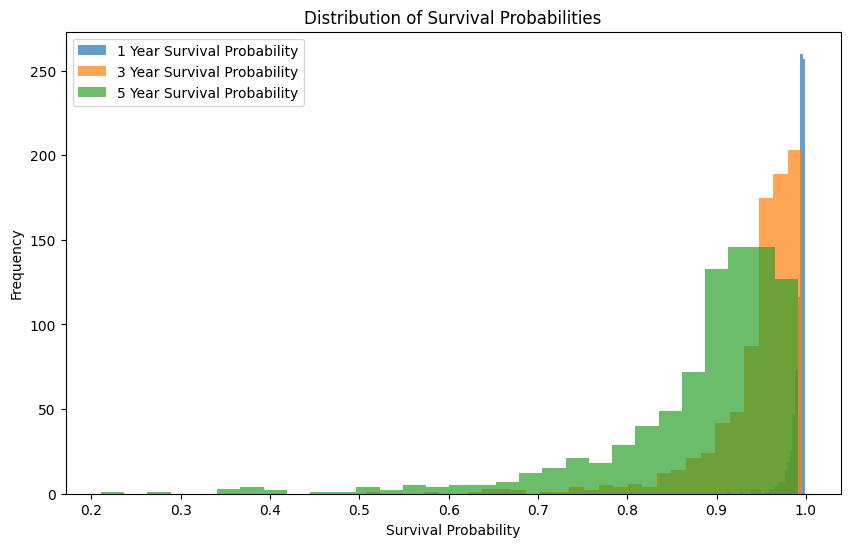

In [92]:
# plot distribution of survival probabilities
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(x_test_df['survival_probability_365_days'], bins=30, alpha=0.7, label='1 Year Survival Probability')
plt.hist(x_test_df['survival_probability_1095_days'], bins=30, alpha=0.7, label='3 Year Survival Probability')
plt.hist(x_test_df['survival_probability_1825_days'], bins=30, alpha=0.7, label='5 Year Survival Probability')
plt.title('Distribution of Survival Probabilities')
plt.xlabel('Survival Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [93]:
def c_index_scorer(estimator, X, y): # X=features, y=structured array
    """
    Scoring function to calculate the concordance index (C-index)
    for a scikit-survival estimator in cross-validation.

    Parameters:
    estimator : scikit-learn estimator
        The trained estimator.
    X : array-like, shape (n_samples, n_features)
        The input features.
    y : array-like, shape (n_samples,)
        The structured array containing survival time and event indicator.

    Returns:
    float
        The concordance index (C-index) score.
    """
    try:
      # Predict risk scores using the estimator
      risk_scores = estimator.predict(X)

      # Extract event times and event indicators from the structured array
      event_times = y["overall survival days"]
      event_observed = y["overall survival event"]

      # Calculate the concordance index
      result = concordance_index_censored(event_observed, event_times, risk_scores)
      return result[0]  # Return the C-index value

    except Exception as e:
      print(f"Error in c_index_scorer: {e}")
      return np.nan  # Return NaN if an error occurs

In [94]:
from sklearn.model_selection import GridSearchCV
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('coxnet', CoxnetSurvivalAnalysis(fit_baseline_model=True))
])

# Define the parameter grid
param_grid = {
    'coxnet__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 1.0],  # Test different l1_ratio values
    'coxnet__alpha_min_ratio': [0.01, 0.05, 0.1, 0.2]  # Test different alpha_min_ratio values
}

# Create GridSearchCV
cv = KFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, scoring=c_index_scorer, cv=cv, n_jobs=-1)



In [95]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Use the best estimator
best_estimator = grid_search.best_estimator_

Best parameters: {'coxnet__alpha_min_ratio': 0.05, 'coxnet__l1_ratio': 0.1}
Best score: 0.7686089150271835


In [96]:
estimator = pickle.load(open('estimator_survival_clinical.pkl', 'rb'))
scaler = pickle.load(open('scaler_survival_clinical.pkl', 'rb'))

def get_best_outcome_threatment(clinical_data:pd.DataFrame, days:int=365, estimator:CoxnetSurvivalAnalysis=estimator, scaler:StandardScaler=scaler) -> pd.DataFrame:
    """ This function takes a clinical data DataFrame and returns the best treatment outcome for each patient.
    Args:
        clinical_data (pd.DataFrame): DataFrame containing clinical data with features and survival information.
    Returns:
        daraframe: A dataframe with the treatments survival probabilities
    """
    # Ensure the clinical data is in the correct format
    data = clinical_data.copy()
    data_endocrine = data.copy()
    data_chemo = data.copy()
    data_both = data.copy()
    data_none = data.copy()
    data_endocrine['endocrine treated']= 1
    data_endocrine['chemo treated'] = 0
    data_chemo['endocrine treated'] = 0
    data_chemo['chemo treated'] = 1
    data_both['endocrine treated'] = 1
    data_both['chemo treated'] = 1
    data_none['endocrine treated'] = 0
    data_none['chemo treated'] = 0
    # Scale the data
    data_endocrine_scaled = scaler.transform(data_endocrine)
    data_chemo_scaled = scaler.transform(data_chemo)
    data_both_scaled = scaler.transform(data_both)
    data_none_scaled = scaler.transform(data_none)
    # Predict survival probabilities for each treatment
    y_pred_endocrine = estimator.predict(data_endocrine_scaled)
    y_pred_chemo = estimator.predict(data_chemo_scaled)
    y_pred_both = estimator.predict(data_both_scaled)
    y_pred_none = estimator.predict(data_none_scaled)
    # Calculate cumulative hazard functions for each treatment
    chf_endocrine = estimator.predict_cumulative_hazard_function(data_endocrine_scaled)
    chf_chemo = estimator.predict_cumulative_hazard_function(data_chemo_scaled)
    chf_both = estimator.predict_cumulative_hazard_function(data_both_scaled)
    chf_none = estimator.predict_cumulative_hazard_function(data_none_scaled)
    # Calculate survival probabilities at the specified time point
    survival_probabilities = {
        "endocrine": [np.exp(-chf(days)) for chf in chf_endocrine],
        "chemo": [np.exp(-chf(days)) for chf in chf_chemo],
        "both": [np.exp(-chf(days)) for chf in chf_both],
        "none": [np.exp(-chf(days)) for chf in chf_none],
    }
    
    # convert to DataFrame
    survival_probabilities = pd.DataFrame(survival_probabilities)
    # Add the best treatment outcome for each patient
    survival_probabilities['best_treatment'] = survival_probabilities.idxmax(axis=1)

    return survival_probabilities

In [97]:
one_person = expression_df.iloc[0:2,:]  # Select one person
one_person.drop(columns=['overall survival days', 'overall survival event'], inplace=True)  # Drop survival columns for feature matrix
best_outcome = get_best_outcome_threatment(one_person, days=365)
best_outcome

/tmp/ipykernel_333950/1211952438.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_person.drop(columns=['overall survival days', 'overall survival event'], inplace=True)  # Drop survival columns for feature matrix


,endocrine,chemo,both,none,best_treatment
0,0.997275,0.997010,0.997275,0.997010,endocrine
1,0.998033,0.997841,0.998033,0.997841,endocrine


In [98]:
one_person.columns

Index(['age at diagnosis', 'tumor size', 'lymph node group',
       'lymph node status', 'er status', 'pgr status', 'her2 status',
       'ki67 status', 'nhg', 'pam50 subtype', 'endocrine treated',
       'chemo treated'],
      dtype='object')

In [99]:
one_person

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated
F1,43,9.0,2,0,False,False,False,True,True,0,False,True
F2,48,14.0,0,1,True,True,False,False,True,2,True,True


In [100]:
one_person

,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,nhg,pam50 subtype,endocrine treated,chemo treated
F1,43,9.0,2,0,False,False,False,True,True,0,False,True
F2,48,14.0,0,1,True,True,False,False,True,2,True,True
